Num GPUs Available:  1
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True
Metal device set to: Apple M4 Max


In [2]:
bands_list = [
    list(range(1,13)),
    [10,9,2],
    [11,9,2],
    [9],
    [10],
    [11],
    [12],
    list(range(1,9)),
    [5,3,2]
]

labels = [
    "All Bands",
    "Bands 10/9/2",
    "Bands 11/9/2",
    "Band 9",
    "Band 10",
    "Band 11",
    "Band 12",
    "Bands 1-8",
    "Bands 5/3/2"
]
mean_metrics = []
std_metrics = []

for bands, label in zip(bands_list, labels):
    print(f"Training with bands {bands} ({label})")
    _, m, s = train_and_store(bands, segmentation=True, runs=10)
    print(f"Mean metrics: {m}, Std metrics: {s}")
    print("-" * 40)
    mean_metrics.append(m)
    std_metrics.append(s)


Training with bands [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] (All Bands)
train images: 778
test images: 9

🚀 Starting training run 1/10
Loading pretrained weights from ./data/model_weights/bands_1_2_3_4_5_6_7_8_9_10_11_12_segmenter_trial1.h5

📊 Evaluating model from run 1 on test dataset:
✅ Run 1 results:
   🔹 loss: 0.0862
   🔹 mean_iou: 0.7586
   🔹 precision: 0.6208
   🔹 recall: 0.8342
   🔹 accuracy: 0.9662

🚀 Starting training run 2/10
Loading pretrained weights from ./data/model_weights/bands_1_2_3_4_5_6_7_8_9_10_11_12_segmenter_trial2.h5

📊 Evaluating model from run 2 on test dataset:
✅ Run 2 results:
   🔹 loss: 0.0904
   🔹 mean_iou: 0.7601
   🔹 precision: 0.6435
   🔹 recall: 0.7989
   🔹 accuracy: 0.9677

🚀 Starting training run 3/10
Loading pretrained weights from ./data/model_weights/bands_1_2_3_4_5_6_7_8_9_10_11_12_segmenter_trial3.h5

📊 Evaluating model from run 3 on test dataset:
✅ Run 3 results:
   🔹 loss: 0.1258
   🔹 mean_iou: 0.7290
   🔹 precision: 0.5341
   🔹 recall: 0.9006

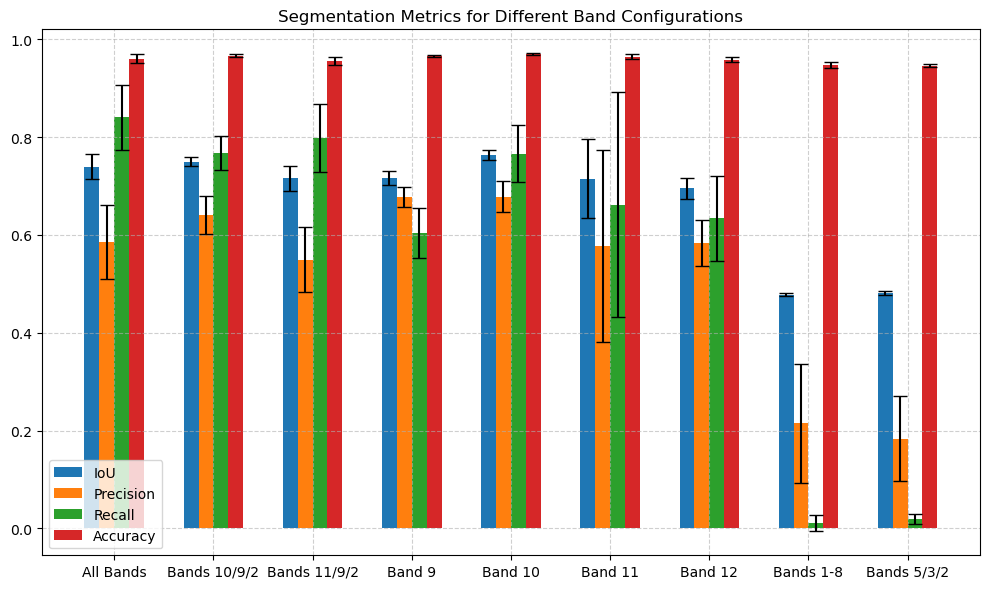

In [4]:
import numpy as np

x = np.arange(len(labels))  # metrics on x-axis
width = 0.15  # bar width

fig, ax = plt.subplots(figsize=(10, 6))

iou_means = [m[1] for m in mean_metrics]  # assuming index 1 = IoU
iou_stds  = [s[1] for s in std_metrics]

precision_means = [m[2] for m in mean_metrics]  # assuming index 2 = Precision
precision_stds  = [s[2] for s in std_metrics]

recall_means = [m[3] for m in mean_metrics]
recall_stds  = [s[3] for s in std_metrics]

accuracy_means = [m[4] for m in mean_metrics]  # assuming index 4 = Accuracy
accuracy_stds  = [s[4] for s in std_metrics]

ax.bar(x, iou_means, width, yerr=iou_stds, capsize=5, label='IoU')
ax.bar(x + width, precision_means, width, yerr=precision_stds, capsize=5, label='Precision')
ax.bar(x + 2 * width, recall_means, width, yerr=recall_stds, capsize=5, label='Recall')
ax.bar(x + 3 * width, accuracy_means, width, yerr=accuracy_stds, capsize=5, label='Accuracy')



# ax.set_xlabel('Bands')
# ax.set_ylabel('')
ax.set_title('Segmentation Metrics for Different Band Configurations')
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(labels)
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()